# MSE 546 - Gradient Boosting: Detecting AI-Generated Text

**Team 13**

This notebook implements a gradient boosting model using **scikit-learn's HistGradientBoostingClassifier** — the same histogram-based algorithm used by XGBoost and LightGBM, with no extra dependencies.

**Approach:**
1. **TF-IDF features** — larger vocabulary than baseline
2. **Stylometric features** — hand-crafted writing style statistics
3. **HistGradientBoostingClassifier** — fast gradient boosting, native on all platforms

**Why gradient boosting over Logistic Regression (baseline)?**
- Builds an ensemble of decision trees sequentially; each tree corrects errors of the previous
- Captures **non-linear interactions** between features that logistic regression cannot
- Handles mixed feature types (sparse TF-IDF + dense numeric)
- Generally outperforms linear models on tabular/feature data

---

## Step 0: Colab Setup (skip if running locally)

In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

if IN_COLAB:
    from google.colab import files
    if not os.path.exists('train_v4_drcat_01.csv'):
        print("Please upload 'train_v4_drcat_01.csv'")
        uploaded = files.upload()

Running locally


---

## Step 1: Import Libraries and Load Data

In [2]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve
)

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print("All libraries imported successfully!")

RANDOM_STATE = 42

scikit-learn version: 1.3.0
All libraries imported successfully!


In [3]:
# Load data
possible_paths = [
    "train_v4_drcat_01.csv",
    "DAIGT-V4-TRAIN-DATASEt/train_v4_drcat_01.csv",
    "../DAIGT-V4-TRAIN-DATASEt/train_v4_drcat_01.csv",
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError("Could not find train_v4_drcat_01.csv")

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nClass percentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))
df.head()

Loading data from: train_v4_drcat_01.csv
Dataset shape: (73573, 6)
Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'model']

Class distribution:
label
1    46203
0    27370
Name: count, dtype: int64

Class percentages:
label
1    62.8
0    37.2
Name: proportion, dtype: float64


,text,label,prompt_name,source,RDizzl3_seven,model
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False,human
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False,human
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False,human
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False,human
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False,human


---

## Step 2: Feature Engineering

We build **two types of features** and combine them:

### 2a. TF-IDF Features
Captures vocabulary patterns — AI models tend to use certain words/phrases more consistently than humans.

### 2b. Stylometric Features
AI text has different *style* from human writing, independent of specific words:
- **Sentence length uniformity**: AI tends to write more uniform sentence lengths
- **Contractions**: Humans use *don't*, *I'm*, *can't* far more than AI
- **Transition words**: AI overuses *furthermore*, *moreover*, *in conclusion*
- **Lexical diversity**: Type-token ratio (unique words / total words)
- **Punctuation patterns**: Different comma, colon, exclamation usage

In [4]:
def extract_stylometric_features(texts):
    """
    Extract hand-crafted stylometric features from a list of texts.
    Returns a numpy array of shape (n_samples, n_features) and a list of feature names.
    """
    features = []

    CONTRACTION_RE = re.compile(
        r"\b(don't|can't|won't|wouldn't|couldn't|shouldn't|isn't|aren't|"
        r"wasn't|weren't|i'm|i've|i'll|i'd|you're|he's|she's|it's|"
        r"we're|they're|that's|there's|here's|let's|who's|what's)\b",
        re.IGNORECASE
    )

    TRANSITION_WORDS = [
        'furthermore', 'moreover', 'additionally', 'however', 'nevertheless',
        'consequently', 'therefore', 'thus', 'in conclusion', 'in summary',
        'overall', 'ultimately', 'in contrast', 'on the other hand',
        'for instance', 'for example', 'specifically', 'notably', 'indeed'
    ]

    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0.0] * 20)
            continue

        # Character and word counts
        char_count = len(text)
        words = text.split()
        word_count = max(len(words), 1)

        # Sentences
        sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
        sentence_count = max(len(sentences), 1)

        # Paragraphs
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
        paragraph_count = max(len(paragraphs), 1)

        # Word length stats
        word_lengths = [len(w) for w in words]
        avg_word_length = np.mean(word_lengths)
        std_word_length = np.std(word_lengths)

        # Sentence length stats
        sent_lengths = [len(s.split()) for s in sentences]
        avg_sent_length = np.mean(sent_lengths)
        std_sent_length = np.std(sent_lengths)
        max_sent_length = np.max(sent_lengths)
        min_sent_length = np.min(sent_lengths)

        # Punctuation rates
        comma_rate       = text.count(',') / word_count
        semicolon_rate   = text.count(';') / word_count
        colon_rate       = text.count(':') / word_count
        exclamation_rate = text.count('!') / word_count
        question_rate    = text.count('?') / word_count

        # Contraction rate (strong human signal)
        contraction_count = len(CONTRACTION_RE.findall(text))
        contraction_rate  = contraction_count / word_count

        # Transition word rate (strong AI signal)
        text_lower = text.lower()
        transition_count = sum(text_lower.count(t) for t in TRANSITION_WORDS)
        transition_rate  = transition_count / sentence_count

        # Lexical diversity: type-token ratio
        unique_words = set(w.lower() for w in words)
        ttr = len(unique_words) / word_count

        # Uppercase ratio
        uppercase_rate = sum(1 for c in text if c.isupper()) / max(char_count, 1)

        # Avg paragraph length
        para_lengths = [len(p.split()) for p in paragraphs]
        avg_para_length = np.mean(para_lengths)

        features.append([
            char_count, word_count, sentence_count, paragraph_count,
            avg_word_length, std_word_length,
            avg_sent_length, std_sent_length, max_sent_length, min_sent_length,
            comma_rate, semicolon_rate, colon_rate,
            exclamation_rate, question_rate,
            contraction_rate, transition_rate,
            ttr, uppercase_rate, avg_para_length,
        ])

    feature_names = [
        'char_count', 'word_count', 'sentence_count', 'paragraph_count',
        'avg_word_length', 'std_word_length',
        'avg_sent_length', 'std_sent_length', 'max_sent_length', 'min_sent_length',
        'comma_rate', 'semicolon_rate', 'colon_rate',
        'exclamation_rate', 'question_rate',
        'contraction_rate', 'transition_rate',
        'type_token_ratio', 'uppercase_rate', 'avg_para_length',
    ]

    return np.array(features, dtype=np.float32), feature_names

print("Feature extraction function defined.")

Feature extraction function defined.


In [5]:
# Prepare labels and split
X = df['text'].fillna('')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training: {len(X_train):,} essays")
print(f"Test:     {len(X_test):,} essays")

Training: 58,858 essays
Test:     14,715 essays


In [6]:
# === TF-IDF Features ===
print("Building TF-IDF features...")

tfidf = TfidfVectorizer(
    max_features=50000,     # 5x larger than baseline
    ngram_range=(1, 3),     # unigrams, bigrams, trigrams
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,      # log(1 + tf) scaling — helps with common words
    strip_accents='unicode',
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF features: {X_train_tfidf.shape[1]:,}")

Building TF-IDF features...
TF-IDF features: 50,000


In [7]:
# === Stylometric Features ===
print("Extracting stylometric features (may take ~1 minute)...")

X_train_style, style_names = extract_stylometric_features(X_train.tolist())
X_test_style, _            = extract_stylometric_features(X_test.tolist())

# Scale so gradient boosting doesn't need to waste splits on scale differences
scaler = StandardScaler()
X_train_style_scaled = scaler.fit_transform(X_train_style)
X_test_style_scaled  = scaler.transform(X_test_style)

print(f"Stylometric features: {X_train_style_scaled.shape[1]}")
print(f"Feature names: {style_names}")

Extracting stylometric features (may take ~1 minute)...
Stylometric features: 20
Feature names: ['char_count', 'word_count', 'sentence_count', 'paragraph_count', 'avg_word_length', 'std_word_length', 'avg_sent_length', 'std_sent_length', 'max_sent_length', 'min_sent_length', 'comma_rate', 'semicolon_rate', 'colon_rate', 'exclamation_rate', 'question_rate', 'contraction_rate', 'transition_rate', 'type_token_ratio', 'uppercase_rate', 'avg_para_length']


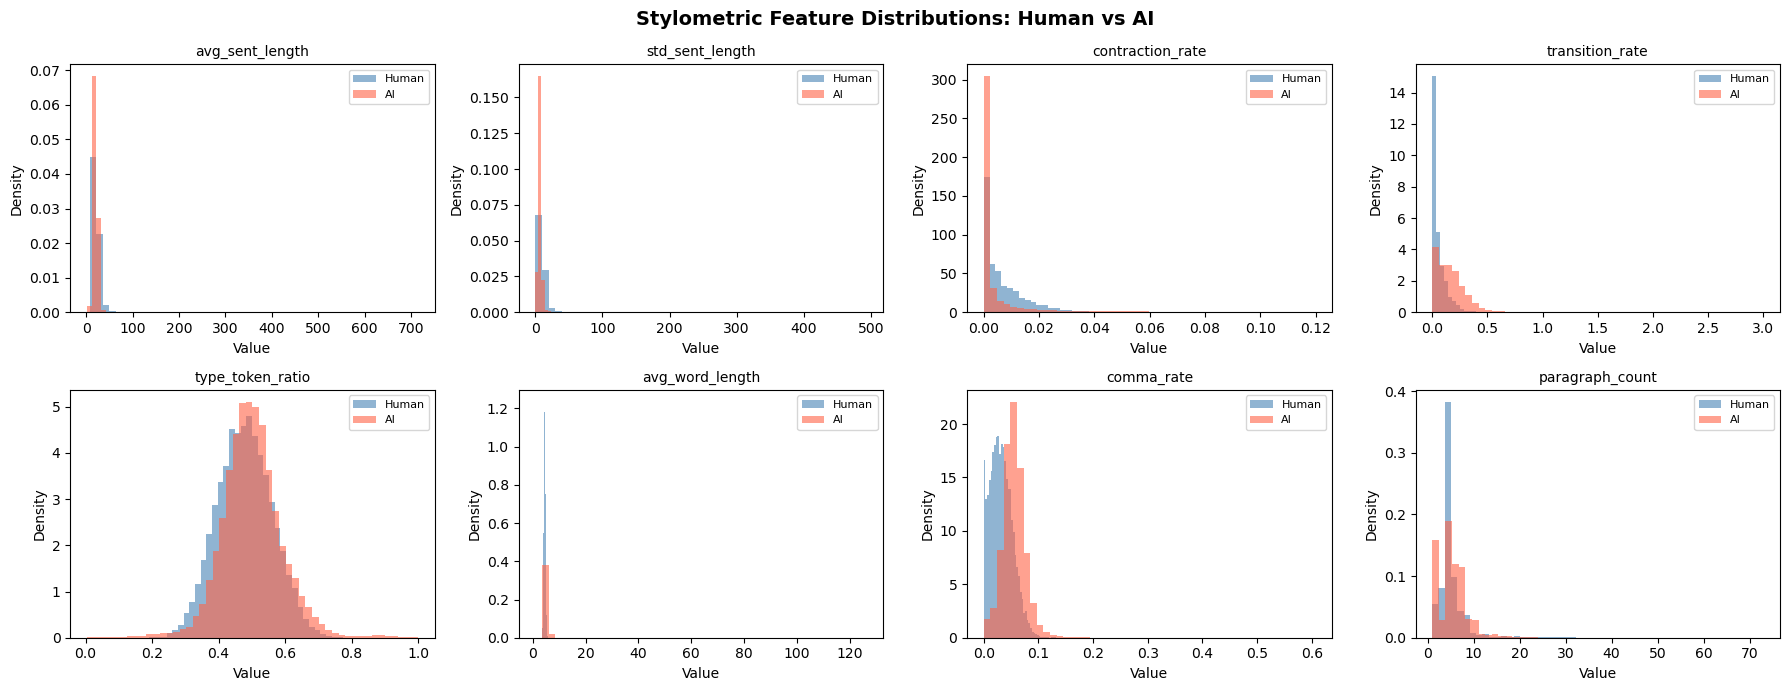

In [8]:
# === Visualize: Do stylometric features separate human vs AI? ===
style_df = pd.DataFrame(X_train_style, columns=style_names)
style_df['label'] = y_train.values

key_features = [
    'avg_sent_length', 'std_sent_length', 'contraction_rate',
    'transition_rate', 'type_token_ratio', 'avg_word_length',
    'comma_rate', 'paragraph_count'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, feat in zip(axes.flatten(), key_features):
    human_vals = style_df[style_df['label'] == 0][feat]
    ai_vals    = style_df[style_df['label'] == 1][feat]
    ax.hist(human_vals, bins=50, alpha=0.6, color='steelblue', label='Human', density=True)
    ax.hist(ai_vals,    bins=50, alpha=0.6, color='tomato',    label='AI',    density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

plt.suptitle('Stylometric Feature Distributions: Human vs AI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# === Combine TF-IDF + Stylometric ===
# Converting 50k-feature sparse TF-IDF to dense would require ~23 GB RAM and crash the kernel.
# Instead, use TruncatedSVD (LSA) to compress TF-IDF to 300 dense components (~100 MB).
from sklearn.decomposition import TruncatedSVD

print("Reducing TF-IDF with TruncatedSVD (LSA)...")
SVD_COMPONENTS = 300
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
X_train_tfidf_reduced = svd.fit_transform(X_train_tfidf)
X_test_tfidf_reduced  = svd.transform(X_test_tfidf)
print(f"Explained variance ratio (first {SVD_COMPONENTS} components): {svd.explained_variance_ratio_.sum():.3f}")

# Stack dense SVD components + dense stylometric features
X_train_combined = np.hstack([X_train_tfidf_reduced, X_train_style_scaled])
X_test_combined  = np.hstack([X_test_tfidf_reduced,  X_test_style_scaled])

print(f"\nCombined feature matrix (train): {X_train_combined.shape}")
print(f"  SVD-compressed TF-IDF: {X_train_tfidf_reduced.shape[1]}")
print(f"  Stylometric features:  {X_train_style_scaled.shape[1]}")
print(f"  Total:                 {X_train_combined.shape[1]}")

Reducing TF-IDF with TruncatedSVD (LSA)...
Explained variance ratio (first 300 components): 0.247

Combined feature matrix (train): (58858, 320)
  SVD-compressed TF-IDF: 300
  Stylometric features:  20
  Total:                 320


---

## Step 3: Train Gradient Boosting Model

**HistGradientBoostingClassifier** is scikit-learn's fast gradient boosting implementation:
- Uses histogram-based splits (same core algorithm as XGBoost `hist` mode and LightGBM)
- Native support for missing values
- Supports early stopping via validation set
- No external dependencies — works on all platforms

**Key hyperparameters:**
- `max_iter`: Number of boosting rounds (trees)
- `max_depth`: Maximum tree depth — controls complexity
- `learning_rate`: Shrinkage factor — smaller = more robust, needs more trees
- `l2_regularization`: Prevents overfitting
- `min_samples_leaf`: Minimum samples per leaf — smooths the model

In [10]:
print("Training Gradient Boosting model...")
print("(This may take a few minutes)")

gb_model = HistGradientBoostingClassifier(
    max_iter=500,               # Up to 500 boosting rounds
    max_depth=6,                # Each tree up to depth 6
    learning_rate=0.05,         # Small learning rate for robustness
    l2_regularization=0.1,      # L2 penalty on leaf values
    min_samples_leaf=20,        # At least 20 samples per leaf
    max_leaf_nodes=63,          # Controls complexity (2^6 - 1)
    early_stopping=True,        # Stop when validation score stops improving
    validation_fraction=0.1,    # 10% of training data used for early stopping
    n_iter_no_change=20,        # Stop after 20 rounds of no improvement
    scoring='roc_auc',          # Optimize for AUC (same metric as competition)
    random_state=RANDOM_STATE,
    verbose=1,
)

gb_model.fit(X_train_combined, y_train)

print(f"\nTraining complete!")
print(f"Actual iterations used: {gb_model.n_iter_}  (early stopping kicked in)")

Training Gradient Boosting model...
(This may take a few minutes)
Binning 0.136 GB of training data: 3.760 s
Binning 0.015 GB of validation data: 0.099 s
Fitting gradient boosted rounds:
[1/500] 1 tree, 61 leaves, max depth = 6, train score: 0.97447, val score: 0.97387, in 0.100s
[2/500] 1 tree, 59 leaves, max depth = 6, train score: 0.98290, val score: 0.98056, in 0.071s
[3/500] 1 tree, 58 leaves, max depth = 6, train score: 0.98362, val score: 0.98138, in 0.091s
[4/500] 1 tree, 57 leaves, max depth = 6, train score: 0.98649, val score: 0.98427, in 0.074s
[5/500] 1 tree, 59 leaves, max depth = 6, train score: 0.98849, val score: 0.98625, in 0.065s
[6/500] 1 tree, 57 leaves, max depth = 6, train score: 0.98891, val score: 0.98704, in 0.065s
[7/500] 1 tree, 61 leaves, max depth = 6, train score: 0.98927, val score: 0.98732, in 0.071s
[8/500] 1 tree, 57 leaves, max depth = 6, train score: 0.98936, val score: 0.98775, in 0.075s
[9/500] 1 tree, 60 leaves, max depth = 6, train score: 0.9901

[86/500] 1 tree, 59 leaves, max depth = 6, train score: 0.99926, val score: 0.99847, in 0.150s
[87/500] 1 tree, 63 leaves, max depth = 6, train score: 0.99929, val score: 0.99850, in 0.155s
[88/500] 1 tree, 51 leaves, max depth = 6, train score: 0.99930, val score: 0.99852, in 0.126s
[89/500] 1 tree, 63 leaves, max depth = 6, train score: 0.99933, val score: 0.99855, in 0.154s
[90/500] 1 tree, 45 leaves, max depth = 6, train score: 0.99936, val score: 0.99858, in 0.124s
[91/500] 1 tree, 61 leaves, max depth = 6, train score: 0.99938, val score: 0.99860, in 0.168s
[92/500] 1 tree, 51 leaves, max depth = 6, train score: 0.99939, val score: 0.99862, in 0.130s
[93/500] 1 tree, 59 leaves, max depth = 6, train score: 0.99941, val score: 0.99865, in 0.145s
[94/500] 1 tree, 59 leaves, max depth = 6, train score: 0.99942, val score: 0.99865, in 0.141s
[95/500] 1 tree, 49 leaves, max depth = 6, train score: 0.99943, val score: 0.99866, in 0.132s
[96/500] 1 tree, 46 leaves, max depth = 6, train s

[172/500] 1 tree, 42 leaves, max depth = 6, train score: 0.99996, val score: 0.99921, in 0.161s
[173/500] 1 tree, 43 leaves, max depth = 6, train score: 0.99996, val score: 0.99921, in 0.157s
[174/500] 1 tree, 62 leaves, max depth = 6, train score: 0.99997, val score: 0.99922, in 0.181s
[175/500] 1 tree, 45 leaves, max depth = 6, train score: 0.99997, val score: 0.99922, in 0.162s
[176/500] 1 tree, 39 leaves, max depth = 6, train score: 0.99997, val score: 0.99923, in 0.155s
[177/500] 1 tree, 47 leaves, max depth = 6, train score: 0.99997, val score: 0.99923, in 0.203s
[178/500] 1 tree, 60 leaves, max depth = 6, train score: 0.99997, val score: 0.99923, in 0.242s
[179/500] 1 tree, 45 leaves, max depth = 6, train score: 0.99997, val score: 0.99924, in 0.246s
[180/500] 1 tree, 40 leaves, max depth = 6, train score: 0.99997, val score: 0.99924, in 0.167s
[181/500] 1 tree, 37 leaves, max depth = 6, train score: 0.99997, val score: 0.99924, in 0.164s
[182/500] 1 tree, 62 leaves, max depth =

[258/500] 1 tree, 60 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.180s
[259/500] 1 tree, 33 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.170s
[260/500] 1 tree, 48 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.176s
[261/500] 1 tree, 35 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.168s
[262/500] 1 tree, 38 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.168s
[263/500] 1 tree, 57 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.186s
[264/500] 1 tree, 39 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.172s
[265/500] 1 tree, 58 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.184s
[266/500] 1 tree, 51 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.182s
[267/500] 1 tree, 50 leaves, max depth = 6, train score: 1.00000, val score: 0.99943, in 0.187s
[268/500] 1 tree, 38 leaves, max depth =

[344/500] 1 tree, 40 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.193s
[345/500] 1 tree, 61 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.198s
[346/500] 1 tree, 39 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.217s
[347/500] 1 tree, 63 leaves, max depth = 6, train score: 1.00000, val score: 0.99949, in 0.209s
[348/500] 1 tree, 60 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.205s
[349/500] 1 tree, 63 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.216s
[350/500] 1 tree, 40 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.194s
[351/500] 1 tree, 57 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.217s
[352/500] 1 tree, 42 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.199s
[353/500] 1 tree, 53 leaves, max depth = 6, train score: 1.00000, val score: 0.99948, in 0.202s
[354/500] 1 tree, 60 leaves, max depth =

[430/500] 1 tree, 63 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.230s
[431/500] 1 tree, 41 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.220s
[432/500] 1 tree, 53 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.225s
[433/500] 1 tree, 57 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.225s
[434/500] 1 tree, 52 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.228s
[435/500] 1 tree, 41 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.240s
[436/500] 1 tree, 62 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.239s
[437/500] 1 tree, 59 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.250s
[438/500] 1 tree, 41 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.219s
[439/500] 1 tree, 62 leaves, max depth = 6, train score: 1.00000, val score: 0.99952, in 0.232s
[440/500] 1 tree, 63 leaves, max depth =

---

## Step 4: Evaluate Model

In [11]:
y_pred       = gb_model.predict(X_test_combined)
y_pred_proba = gb_model.predict_proba(X_test_combined)[:, 1]

gb_metrics = {
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
}

print("=" * 55)
print("GRADIENT BOOSTING PERFORMANCE")
print("=" * 55)
for k, v in gb_metrics.items():
    print(f"  {k:12}  {v:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))

GRADIENT BOOSTING PERFORMANCE
  ROC-AUC       0.9995
  Precision     0.9950
  Recall        0.9916
  F1-Score      0.9933

              precision    recall  f1-score   support

   Human (0)       0.99      0.99      0.99      5474
      AI (1)       1.00      0.99      0.99      9241

    accuracy                           0.99     14715
   macro avg       0.99      0.99      0.99     14715
weighted avg       0.99      0.99      0.99     14715



---

## Step 5: Comparison with Baseline

In [18]:
# -------------------------------------------------------
# UPDATE these values with your actual baseline numbers!
# (copy from the output of baseline_model.ipynb)
# -------------------------------------------------------
BASELINE = {
    'ROC-AUC':   0.9924,
    'Precision': 0.9810,
    'Recall':    0.9595,
    'F1-Score':  0.9701,
}

# print("NOTE: Update BASELINE above with your actual baseline numbers!\n")

comparison = pd.DataFrame({'Baseline (TF-IDF + LR)': BASELINE, 'Gradient Boosting': gb_metrics}).T
comparison['Improvement'] = comparison['ROC-AUC'] - BASELINE['ROC-AUC']

print("=" * 65)
print("MODEL COMPARISON")
print("=" * 65)
print(comparison.to_string())
print("=" * 65)

MODEL COMPARISON
                         ROC-AUC  Precision    Recall  F1-Score  Improvement
Baseline (TF-IDF + LR)  0.992400   0.981000  0.959500  0.970100     0.000000
Gradient Boosting       0.999535   0.995005  0.991559  0.993279     0.007135


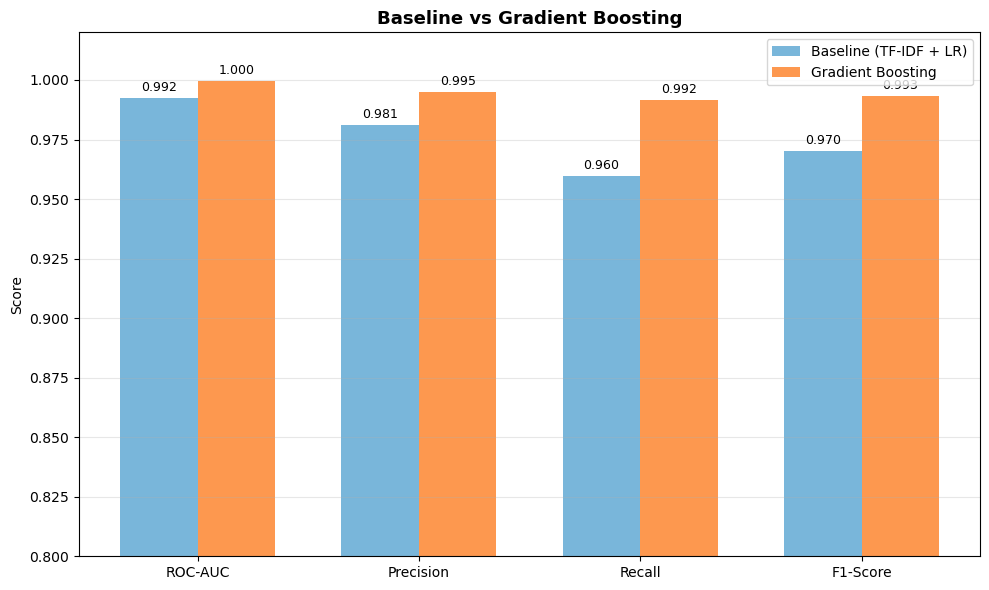

In [19]:
# Bar chart
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [BASELINE[m] for m in metrics],   width, label='Baseline (TF-IDF + LR)', color='#6baed6', alpha=0.9)
bars2 = ax.bar(x + width/2, [gb_metrics[m] for m in metrics], width, label='Gradient Boosting',       color='#fd8d3c', alpha=0.9)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.02)
ax.set_title('Baseline vs Gradient Boosting', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

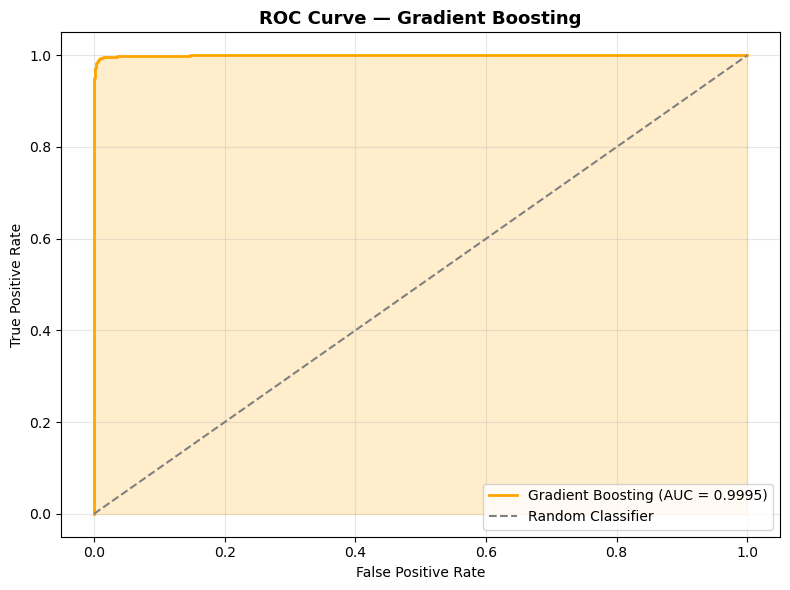

In [20]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2,
         label=f'Gradient Boosting (AUC = {gb_metrics["ROC-AUC"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.2, color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Gradient Boosting', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 6: Confusion Matrix

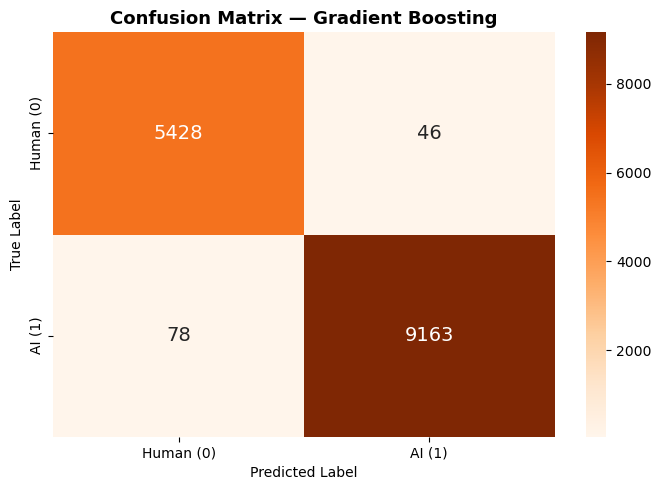

True Negatives  (Human→Human): 5,428
False Positives (Human→AI):    46
False Negatives (AI→Human):    78
True Positives  (AI→AI):       9,163


In [21]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'],
            annot_kws={'size': 14})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True Negatives  (Human→Human): {tn:,}")
print(f"False Positives (Human→AI):    {fp:,}")
print(f"False Negatives (AI→Human):    {fn:,}")
print(f"True Positives  (AI→AI):       {tp:,}")

---

## Step 7: Feature Importance

Which stylometric features contributed most? We use **permutation importance** — measure how much the AUC drops when each feature is randomly shuffled.

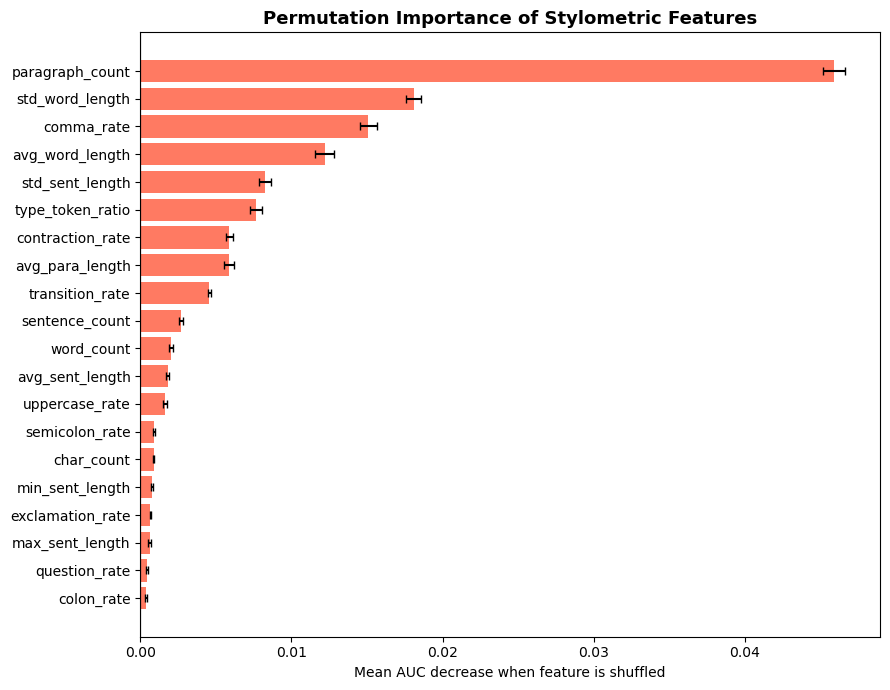


Stylometric feature importances (sorted):
         feature  importance      std
 paragraph_count    0.045896 0.000720
 std_word_length    0.018084 0.000522
      comma_rate    0.015092 0.000569
 avg_word_length    0.012200 0.000622
 std_sent_length    0.008271 0.000387
type_token_ratio    0.007659 0.000426
contraction_rate    0.005906 0.000262
 avg_para_length    0.005875 0.000328
 transition_rate    0.004575 0.000110
  sentence_count    0.002675 0.000141
      word_count    0.002009 0.000130
 avg_sent_length    0.001825 0.000099
  uppercase_rate    0.001637 0.000115
  semicolon_rate    0.000915 0.000068
      char_count    0.000879 0.000065
 min_sent_length    0.000790 0.000059
exclamation_rate    0.000651 0.000033
 max_sent_length    0.000633 0.000102
   question_rate    0.000446 0.000053
      colon_rate    0.000363 0.000062


In [22]:
from sklearn.inspection import permutation_importance

# Only run permutation importance on the stylometric features (last 20 columns)
# Running on all 50k features would be very slow
n_style = X_train_style_scaled.shape[1]
X_style_only_test = X_test_combined[:, -n_style:]  # last n_style columns

# Train a small model on just stylometric features to check their standalone importance
gb_style_only = HistGradientBoostingClassifier(
    max_iter=200, max_depth=4, learning_rate=0.1, random_state=RANDOM_STATE
)
gb_style_only.fit(X_train_combined[:, -n_style:], y_train)

result = permutation_importance(
    gb_style_only, X_style_only_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    style_names,
    'importance': result.importances_mean,
    'std':        result.importances_std,
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in perm_df['importance']]
plt.barh(perm_df['feature'], perm_df['importance'],
         xerr=perm_df['std'], color=colors, alpha=0.85, capsize=3)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Mean AUC decrease when feature is shuffled')
plt.title('Permutation Importance of Stylometric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStylometric feature importances (sorted):")
print(perm_df.sort_values('importance', ascending=False)[['feature','importance','std']].to_string(index=False))

---

## Step 8: Summary

In [23]:
print("=" * 65)
print("SUMMARY: Gradient Boosting with Stylometric Features")
print("=" * 65)
print(f"""
Model: HistGradientBoostingClassifier (sklearn)
  - Same histogram-based algorithm as XGBoost/LightGBM
  - No external dependencies
  - Early stopping used: {gb_model.n_iter_} iterations

Features:
  - TF-IDF:         {X_train_tfidf.shape[1]:,} (unigrams + bigrams + trigrams)
  - Stylometric:    {len(style_names)} hand-crafted writing-style features
  - Total:          {X_train_combined.shape[1]:,}

Performance:
  ROC-AUC:   {gb_metrics['ROC-AUC']:.4f}  (baseline: {BASELINE['ROC-AUC']:.4f}, delta: {gb_metrics['ROC-AUC'] - BASELINE['ROC-AUC']:+.4f})
  Precision: {gb_metrics['Precision']:.4f}
  Recall:    {gb_metrics['Recall']:.4f}
  F1-Score:  {gb_metrics['F1-Score']:.4f}  (baseline: {BASELINE['F1-Score']:.4f}, delta: {gb_metrics['F1-Score'] - BASELINE['F1-Score']:+.4f})

Key advantages over baseline (Logistic Regression):
  - Captures non-linear feature interactions
  - More expressive model (ensemble of 500 trees)
  - Stylometric features add signal bag-of-words misses
  - Regularization via L2 + early stopping
""")
print("=" * 65)

SUMMARY: Gradient Boosting with Stylometric Features

Model: HistGradientBoostingClassifier (sklearn)
  - Same histogram-based algorithm as XGBoost/LightGBM
  - No external dependencies
  - Early stopping used: 500 iterations

Features:
  - TF-IDF:         50,000 (unigrams + bigrams + trigrams)
  - Stylometric:    20 hand-crafted writing-style features
  - Total:          320

Performance:
  ROC-AUC:   0.9995  (baseline: 0.9924, delta: +0.0071)
  Precision: 0.9950
  Recall:    0.9916
  F1-Score:  0.9933  (baseline: 0.9701, delta: +0.0232)

Key advantages over baseline (Logistic Regression):
  - Captures non-linear feature interactions
  - More expressive model (ensemble of 500 trees)
  - Stylometric features add signal bag-of-words misses
  - Regularization via L2 + early stopping

